In [ ]:
# Installations
# !pip install torch git+https://github.com/huggingface/transformers
# !pip install jupyterlab ipywidgets bertviz evaluate matplotlib

# 1). Tokenizers (Using Hugging face Transformers)

In [ ]:
from transformers import BertModel, BertTokenizer

modelname = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(modelname)
model = BertModel.from_pretrained(modelname)
# Example text to encode
text = "Hello, how are you?"
# Tokenize the text
tokenized = tokenizer(text)
print ("Tokenized output:") 
print(tokenized)

# Code Explanation:
# This code demonstrates how to use the Hugging Face Transformers library to load a pre-trained BERT model and 
# its tokenizer, and then tokenize a sample text..

# The tokenizer is loaded using BertTokenizer.from_pretrained(modelname). 
# This tokenizer is responsible for converting raw text into the numerical format (Tokens and Token IDs) that the BERT model can process. 
# The model consumes these token IDs to perform tasks like classification, generation, etc.

# Similarly, BertModel.from_pretrained(modelname) loads the actual BERT model with its pre-trained weights.
# The result, stored in tokenized, is a dictionary containing the token IDs and other relevant information needed for the model. 

# What is Hugging face?
# Hugging Face is a open-source platform and community for building, sharing, and collaborating on machine learning models—especially in NLP computer vision, and Gen AI.

# What is Hugging face Transformers?
# Hugging Face Transformers is an open-source library that provides a wide range of pre-trained models for NLP tasks.
# It supports various architectures like BERT, GPT, RoBERTa, and more.
# The library simplifies the process of using these models for tasks such as text classification, translation, question answering, and text generation. 
# It also includes tokenizers that convert raw text into a format suitable for model input.

# What is Tokenization?
# Tokenization is the process of converting raw text into a format that can be processed by machine learning models.
# Tokenization involves breaking down text into smaller units, such as words or subwords, and converting them into numerical representations (token IDs).
# Token IDs are numerical representations of tokens that the model can understand.
# The tokenizer converts raw text into token IDs, which are then used as input to the model

# The output of the tokenizer is a dictionary containing the tokenized text, including:
# - input_ids: The numerical IDs of the tokens.

Tokenized output:
{'input_ids': [101, 7592, 1010, 2129, 2024, 2017, 1029, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}


In [6]:
# Print tokens from token_ids
tokens = tokenizer.convert_ids_to_tokens(tokenized["input_ids"])
print("Tokens using Token Ids:")
print(tokens)

Tokens using Token Ids:
['[CLS]', 'hello', ',', 'how', 'are', 'you', '?', '[SEP]']


In [ ]:
# Explain Output: 
# {'input_ids': [101, 7592, 1010, 2129, 2024, 2017, 1029, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}
# 
# This pattern is the tokenization of a question, "Hello, how are you?" using the BERT tokenizer (bert-base-uncased).
# 
# 'input_ids': [101, 7592, 1010, 2129, 2024, 2017, 1029, 102]
# These are the token IDs assigned to each word/subword by the tokenizer. 
# Each number corresponds to a specific token in the tokenizer’s vocabulary. 
# The model consumes these token IDs to perform tasks like classification, generation, etc.
#   Token	        ID	  Meaning
#   [CLS]	        101	  Special token marking start
#   hello	        7592	Word piece token
#   , (comma)	    1010	Punctuation
#   how	          2129	Word
#   are	          2024	Word
#   you	          2017	Word
#   ? (question)	1029	Punctuation
#   [SEP]	        102	  Special token marking end
# 
# 
# 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0]
# These IDs help BERT distinguish between sentence A and B in sentence-pair tasks:
# All 0’s → Means it’s a single sentence (not a sentence-pair input)
# 
# 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]
# Tells the model which tokens to pay attention to
# 	1 = Attend to this token
# 	0 = Ignore (e.g. padding tokens, if any)

# 2). Positional Encoding (Highlight importance of word order in a sentence)

In [12]:
# Transformers (like BERT or GPT) process input tokens in parallel, unlike RNNs which read tokens in order. 
# That means RNNs have no inherent sense of token position unless we explicitly provide it.
# So... if you give it: > “Arun paid the bill” vs. “The bill paid Arun” The words are the same, but the meanings are wildly different because of order.
# 
# Thus Positional Encoding: Injects a notion of word order into the model’s input.
# 
# Positional Encoding - 
#     - Is a vector that's added to the token embeddings at each position. 
#     - So instead of just learning what each word means, the model also learns where it appears in the sequence.
#     - There are two main flavors
#         1. Sinusoidal Positional Encoding (used in original Transformers): These are fixed patterns using sine and cosine.
#            This helps the model generalize to longer sequences beyond training data.
#            
#             PE(pos, 2i) = sin(pos / 10000^(2i/d_model))  
#             PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
# 
#             pos: position in the sequence
#             i: dimension index
#             d_model: size of the embedding
# 
#         2. Learned Positional Embedding (used in BERT, GPT): Each position gets its own embedding vector, learned during training.
#            The model figures out the best way to use position info to optimize the task (like classification or generation).

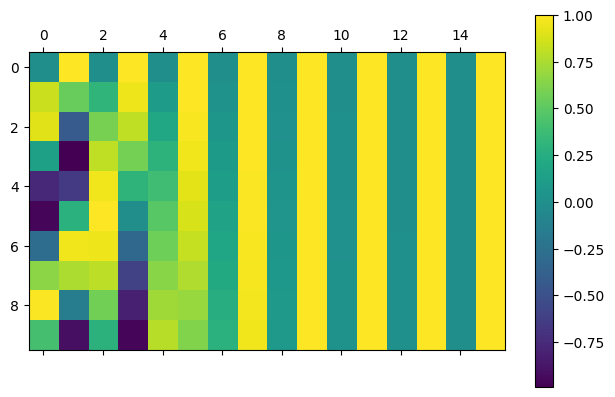

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def encodePositions(num_tokens, depth, n=10000):
    positionalMatrix = np.zeros((num_tokens, depth))
    for row in range(num_tokens):
        for col in np.arange(int(depth/2)):
            denominator = np.power(n, 2*col/depth)
            positionalMatrix[row, 2*col] = np.sin(row/denominator)
            positionalMatrix[row, 2*col+1] = np.cos(row/denominator)
    return positionalMatrix

# Example usage of encodePositions
num_tokens = 10  # Number of tokens 
depth = 16  # Depth of the positional encoding
positional_encoding = encodePositions(num_tokens, depth)    
fig = plt.matshow(positional_encoding)
plt.gcf().colorbar(fig)
plt.show()

# Code Explanation:
# The function encodePositions generates a positional encoding matrix for a given number of tokens and depth.
# It uses sine and cosine functions to create a unique encoding for each position in the sequence.
# The resulting matrix can be used in transformer models to provide positional information about the tokens.

# This code demonstrates how to generate and visualize sinusoidal positional encodings, 
# a technique used in transformer models to inject information about token positions into the model.
# This visualization helps illustrate the repeating and varying patterns of the positional encodings across 
# both positions and embedding dimensions.

# 3). Self-Attention (Heart of the Transformer architecture)

In [ ]:
# Self-attention is the heart of the Transformer architecture—it’s what gives Transformers their superpower. 
# 
# What Is Self-Attention?
#     Imagine you’re reading a sentence and trying to understand the meaning of a word—often, you need to consider other words in the sentence. 
#     Self-attention allows the model to do just that: each word learns to "look at" (i.e., attend to) other words in the sequence when building its own representation.
# 
#     It answers: “How important is every other word in the sentence to the word getting processed currently”
# 
#     How It Works (Step-by-Step)
#         Given an input sequence like ["The", "invoice", "was", "paid"], each word is:
# 
#         1). Embedded → turned into a vector
#         2). Projected into 3 vectors:
#             Query (Q): What this word is asking about
#             Key (K): What this word offers as info
#             Value (V): What we return if the word is relevant
# 
#         3). For each word, compute attention weights:
#             Dot product of Query with all Keys
#             Apply Softmax to get attention scores (normalized importance)
# 
#         4). Multiply scores with corresponding Value vectors → sum them
#             This gives a new representation of the word, based on relevant context
# 
#         This is done for every word in the sequence, in parallel!
# 
#     Intuition with Example
#         Take the sentence: > "The eInvoice was submitted by Arun"
#         To understand “submitted,” the model might attend strongly to:
#             “eInvoice” (what was submitted)
#             “Arun” (who submitted)
# 
#         So “submitted” builds its contextual meaning by weighing other tokens—that's self-attention in action.   

In [14]:
from bertviz.transformers_neuron_view import BertModel, BertTokenizer
from bertviz.neuron_view import show

tokenizer_viz = BertTokenizer.from_pretrained(modelname)
model_viz = BertModel.from_pretrained(modelname)
show(model_viz, "bert", tokenizer_viz, "I read a good novel.", display_mode="light", head=11)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
show(model_viz, "bert", tokenizer_viz, "Donation is a novel idea.", display_mode="light", head=11)

# More to play with: https://huggingface.co/spaces/exbert-project/exbert

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 4). GPT2 (Not BERT) Model (137M parameters)

In [17]:
from transformers import pipeline
generator = pipeline('text-generation', model='gpt2')
generator("I read a good novel.", max_length=30, num_return_sequences=5)

# Code Explanation:
# The code uses the Hugging Face Transformers library to create a 'text generation pipeline' with the GPT-2 model.
# It initializes the pipeline with the 'text-generation' task and specifies the GPT-2 model to be used. 
# The generator function is then called with a prompt ("I read a good novel.") and 
# parameters for maximum length and number of return sequences. 

    # max_length=30 (limiting the generated text to 30 tokens) and 
    # num_return_sequences=5 (requesting five different generated outputs)

# The output will be a list of generated text sequences based on the input prompt.




Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'I read a good novel.\n\nThe second book is called "The Unwritten Contract." It\'s about a time when the government of the United States is on the verge of a meltdown. When a group of military leaders decide to leave the United States, they don\'t go to war, because they don\'t want to be seen as betrayers of their people. But when the government of Israel sets up a terrorist organization against the United States, they are at what I call a critical crossroads. The government of the United States is going through something called the Great Recession, and that causes an explosion of political unrest and a period of civil war in the country.\n\nI think it\'s the same thing that happened to the United States of America. The most prominent example is the Watergate, which was a government attempt to cover up their own complicity in the Watergate scandal. When we found out that the government had used some kind of illegal wiretap system, we thought, Wow, this is a terribl

In [18]:
generator("I read a good novel.", max_length=300, num_return_sequences=5)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=300) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'I read a good novel.\n\nI read a good novel. I heard the Beatles.\n\nI heard the Beatles. I heard the Beatles. I heard the Beatles. I read a good novel.\n\nI read a good novel. I read a good novel. I read a good novel. I read a good novel. I read a good novel. I read a good novel. I read a good novel. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book.\n\nI read a good novel. I read a good novel. I read a good novel. I read a good novel. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book. I read a good book.'},
 {'generated_text': 'I read a good novel. And one of the best books in history was wri